# Rerankers on SQuAD — demo

Companion notebook to **Meeting 15 — Beyond single-stage retrieval (part 1)**.

We measure six retrieval stages on a tiny 100-document slice of SQuAD 1.1:

1. BM25
2. Dense (BGE-small)
3. Hybrid (BM25 + dense, RRF)
4. Hybrid + cross-encoder rerank
5. Hybrid + LLM rerank — **pointwise** (score each candidate)
6. Hybrid + LLM rerank — **listwise** (RankGPT-style: reorder a numbered list in one call)

Only metric reported: **recall@k**. Everything else (MRR, nDCG, latency sweeps, ANN) lives in the M10 demo.

**Data shape.** A single pandas `DataFrame` `df` holds the benchmark. One row per
(paragraph, question) pair. Every retrieval stage **reads** the `context` /
`question` columns and **writes** its ranking back as a new column
(`bm25_ranks`, `dense_ranks`, `hybrid_ranks`, `ce_ranks`, `pw_ranks`, `lw_ranks`).
The row index doubles as the gold document id, so the relevant doc for query
`i` is doc `i`.

**How to run:**

- **Local CPU** — `Run all`. LLM stages need `ANTHROPIC_API_KEY`. The pointwise
  stage is rate-limit-bound (~20 min); everything else is < 1 min.
- **Google Colab** — `Runtime → Change runtime type → T4 GPU`, then `Run all`.

LLM stages degrade gracefully if no API key is set — they are skipped and the
leaderboard rows show `—`.


In [ ]:
# Install dependencies (Colab-friendly; harmless on a local env that already has them)
%pip install -q -U datasets sentence-transformers rank_bm25 anthropic python-dotenv matplotlib pandas


In [46]:
import os, time, json, asyncio, random
from collections import deque, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer, CrossEncoder
from rank_bm25 import BM25Okapi

import anthropic


In [ ]:
# Load ANTHROPIC_API_KEY from common .env locations (no-op if already in env).
from dotenv import load_dotenv
load_dotenv(os.path.expanduser("~/.env"))


In [ ]:
pd.set_option('display.max_colwidth', None)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EMB_MODEL = "BAAI/bge-small-en-v1.5"
CE_MODEL  = "cross-encoder/ms-marco-MiniLM-L-6-v2"
LLM_MODEL = "claude-haiku-4-5"

N_DOCS         = 100   # paragraphs == documents
RERANK_N       = 50    # candidate pool for hybrid / cross-encoder / listwise
POINTWISE_TOPK = 10    # pointwise LLM only reranks top-K from hybrid (rate-limit friendly,
                       # and the realistic production pattern: pointwise after a pre-filter)
TOP_K          = 10    # final cut for leaderboard headline column

# Haiku 4.5 list price (USD / 1M tokens) — used only for the back-of-envelope cost column.
PRICE_IN_PER_M  = 1.00
PRICE_OUT_PER_M = 5.00

# Anthropic per-org rate limit. Tune to your tier (we run conservatively at 45 RPM with a
# 50 RPM ceiling). The SDK retries 429s with backoff; we additionally throttle proactively.
RPM_LIMIT       = 45
LLM_CONCURRENCY = 5

HAS_KEY = bool(os.environ.get("ANTHROPIC_API_KEY"))
print(f"Device: {DEVICE}")
print(f"Embedding model: {EMB_MODEL}")
print(f"Cross-encoder:   {CE_MODEL}")
print(f"LLM model:       {LLM_MODEL}  (API key present: {HAS_KEY})")


## 1. Build the benchmark `df`

Load SQuAD 1.1 (HuggingFace `squad`, train split) into a DataFrame, dedupe to one
question per paragraph, and keep the first `N_DOCS` rows. Every later stage will
read `df['context']` / `df['question']` and write a new ranking column.


In [ ]:
squad_train = load_dataset("squad", split="train")
squad_df = pd.DataFrame(squad_train)
squad_df.head()


In [17]:
# One row per paragraph (keep the first question encountered for each unique context),
# then take the first N_DOCS rows. The row index is the gold document id.
df = (squad_df
        .drop_duplicates(subset='context', keep='first')
        .head(N_DOCS)
        .reset_index(drop=True))

# Convenience views (sentence-transformers / rank_bm25 want plain lists)
paragraphs = df['context'].tolist()
questions  = df['question'].tolist()
gold       = df.index.tolist()             # = [0, 1, ..., N_DOCS-1]

print(f"benchmark: {len(df)} (paragraph, question) pairs")
df[['context', 'question']].head(3)


benchmark: 100 (paragraph, question) pairs


,context,question
0,"Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend ""Venite Ad Me Omnes"". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.",To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
1,"As at most other universities, Notre Dame's students run a number of news media outlets. The nine student-run outlets include three newspapers, both a radio and television station, and several magazines and journals. Begun as a one-page journal in September 1876, the Scholastic magazine is issued twice monthly and claims to be the oldest continuous collegiate publication in the United States. The other magazine, The Juggler, is released twice a year and focuses on student literature and artwork. The Dome yearbook is published annually. The newspapers have varying publication interests, with The Observer published daily and mainly reporting university and other news, and staffed by students from both Notre Dame and Saint Mary's College. Unlike Scholastic and The Dome, The Observer is an independent publication and does not have a faculty advisor or any editorial oversight from the University. In 1987, when some students believed that The Observer began to show a conservative bias, a liberal newspaper, Common Sense was published. Likewise, in 2003, when other students believed that the paper showed a liberal bias, the conservative paper Irish Rover went into production. Neither paper is published as often as The Observer; however, all three are distributed to all students. Finally, in Spring 2008 an undergraduate journal for political science research, Beyond Politics, made its debut.",When did the Scholastic Magazine of Notre dame begin publishing?
2,"The university is the major seat of the Congregation of Holy Cross (albeit not its official headquarters, which are in Rome). Its main seminary, Moreau Seminary, is located on the campus across St. Joseph lake from the Main Building. Old College, the oldest building on campus and located near the shore of St. Mary lake, houses undergraduate seminarians. Retired priests and brothers reside in Fatima House (a former retreat center), Holy Cross House, as well as Columba Hall near the Grotto. The university through the Moreau Seminary has ties to theologian Frederick Buechner. While not Catholic, Buechner has praised writers from Notre Dame and Moreau Seminary created a Buechner Prize for Preaching.",Where is the headquarters of the Congregation of the Holy Cross?


## 2. Metric — `recall@k`

A single relevant doc per query, so for one query

```
recall@k = 1 if gold ∈ retrieved[:k] else 0
```

and we average across queries. (In IR this single-relevant case is often called
**hit@k** — same number.)


In [18]:
def recall_at_k(retrieved_ids, relevant_id, k):
    return 1.0 if relevant_id in retrieved_ids[:k] else 0.0

def recall_curve(rank_series, gold, ks=range(1, 11)):
    '''rank_series: a list/Series of ranking lists; gold: parallel list of gold ids.'''
    return [float(np.mean([recall_at_k(r, g, k) for r, g in zip(rank_series, gold)])) for k in ks]

def headline_recalls(rank_series, gold):
    return {f"recall@{k}": float(np.mean([recall_at_k(r, g, k) for r, g in zip(rank_series, gold)]))
            for k in (1, 3, 5, 10)}

def plot_curves(curves, title, ks=range(1, 11)):
    plt.figure(figsize=(9, 5))
    for label, ys in curves.items():
        plt.plot(list(ks), ys, marker='o', label=label)
    plt.xlabel("k"); plt.ylabel("recall@k")
    plt.title(title); plt.ylim(0, 1.02)
    plt.grid(True, alpha=0.3); plt.legend(loc="lower right")
    plt.tight_layout(); plt.show()


## 3. BM25 baseline → `df['bm25_ranks']`

Whitespace-tokenised, no preprocessing. `BM25Okapi` from `rank_bm25`. For each
query we rank all `N_DOCS` paragraphs and keep the top `RERANK_N` as the candidate
pool. Output: one column on `df` whose value is a list of doc-ids.


In [30]:
def tokenize(s):
    return s.lower().split()

bm25 = BM25Okapi([tokenize(p) for p in df['context']])

t0 = time.time()
df['bm25_ranks'] = [np.argsort(-bm25.get_scores(tokenize(q))).tolist()
                    for q in df['question']]
bm25_secs = time.time() - t0

bm25_metrics = headline_recalls(df['bm25_ranks'], gold)
bm25_metrics["sec_per_query"] = bm25_secs / len(df)
print(json.dumps(bm25_metrics, indent=2))


{
  "recall@1": 0.51,
  "recall@3": 0.7,
  "recall@5": 0.79,
  "recall@10": 0.84,
  "sec_per_query": 0.0001633310317993164
}


## 4. Dense baseline — BGE-small → `df['dense_ranks']`

Encode the paragraphs and questions, dot-product, sort. Same flat search as M10.
Top `RERANK_N` per query is written as a new column on `df`.


In [33]:
%pip install -q chromadb

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

# Persistent local Chroma — data lives in ./chroma_db so re-runs don't re-embed.
chroma_client = chromadb.PersistentClient(path="./chroma_db")
embed_fn = SentenceTransformerEmbeddingFunction(model_name=EMB_MODEL, device=DEVICE)

COLLECTION_NAME = "squad_dense"
collection = chroma_client.get_or_create_collection(
    name=COLLECTION_NAME,
    embedding_function=embed_fn,
    metadata={"hnsw:space": "cosine"},
)

# Index the paragraphs only if the persisted collection doesn't already have them.
# Doc id is the string form of the row index, so we can map back to ints later.
if collection.count() != len(df):
    if collection.count() > 0:
        chroma_client.delete_collection(COLLECTION_NAME)
        collection = chroma_client.create_collection(
            name=COLLECTION_NAME,
            embedding_function=embed_fn,
            metadata={"hnsw:space": "cosine"},
        )
    collection.add(
        ids=[str(i) for i in range(len(df))],
        documents=df['context'].tolist(),
    )

t0 = time.time()
res = collection.query(query_texts=df['question'].tolist(), n_results=len(df))
df['dense_ranks'] = [[int(d) for d in ids] for ids in res['ids']]
dense_secs = time.time() - t0

dense_metrics = headline_recalls(df['dense_ranks'], gold)
dense_metrics["sec_per_query"] = dense_secs / len(df)
print(json.dumps(dense_metrics, indent=2))

Note: you may need to restart the kernel to use updated packages.
{
  "recall@1": 0.64,
  "recall@3": 0.83,
  "recall@5": 0.89,
  "recall@10": 0.95,
  "sec_per_query": 0.004510171413421631
}


## 5. Hybrid — Reciprocal Rank Fusion (RRF) → `df['hybrid_ranks']`

For each rank list, the contribution to doc `d` is `1 / (k0 + rank_of_d)`. Sum
across lists, sort descending. `k0=60` is the value from the original Cormack et al.
(2009) RRF paper.

```
rrf_score(d) = Σ_list 1 / (k0 + rank_in_list(d))
```

Docs that one list missed entirely contribute 0 from that list. Reads
`df['bm25_ranks']` and `df['dense_ranks']`, writes `df['hybrid_ranks']`.


In [32]:
def rrf_fuse(rank_lists, k0=60):
    scores = {}
    for ranks in rank_lists:
        for rank, doc_id in enumerate(ranks):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k0 + rank + 1)
    return [d for d, _ in sorted(scores.items(), key=lambda x: -x[1])]

t0 = time.time()
df['hybrid_ranks'] = [rrf_fuse([row.bm25_ranks, row.dense_ranks])
                      for row in df.itertuples()]
hybrid_secs = time.time() - t0

hybrid_metrics = headline_recalls(df['hybrid_ranks'], gold)
hybrid_metrics["sec_per_query"] = hybrid_secs / len(df)
print(json.dumps(hybrid_metrics, indent=2))

{
  "recall@1": 0.65,
  "recall@3": 0.82,
  "recall@5": 0.88,
  "recall@10": 0.93,
  "sec_per_query": 7.450342178344727e-05
}


## 6. Cross-encoder rerank → `df['ce_ranks']`

`cross-encoder/ms-marco-MiniLM-L-6-v2` — a small BERT trained for MS MARCO passage
ranking. For each query we score all `RERANK_N=50` hybrid candidates as
`(query, paragraph)` pairs and re-sort by score. The candidate **set** doesn't
change — only its **order**.

Reads `df['hybrid_ranks']`, writes `df['ce_ranks']`.


In [34]:
CE_TOPK = 20   # standard pipeline: rerank only the top-K hybrid candidates

# Cross-encoder = one BERT-style model that takes BOTH (query, passage) as input
# and outputs a single relevance score. Slower than dual-encoder retrieval, so we
# only apply it to a small candidate pool from an earlier cheap stage (hybrid).
ce_model = CrossEncoder(CE_MODEL, device=DEVICE)

# Materialise once so each per-candidate lookup `contexts[d]` is O(1).
contexts = df['context'].values   # O(1) lookup by doc id (= row index)

t0 = time.time()
ce_rankings = []
for row in df.itertuples():
    # Head: the top-K candidates we will re-score.
    cand_top = row.hybrid_ranks[:CE_TOPK]

    # CE.predict takes a batch of (query, passage) pairs and returns one score per pair.
    pairs    = [(row.question, contexts[d]) for d in cand_top]
    scores   = ce_model.predict(pairs)

    # np.argsort(-scores) gives indices that sort `scores` descending.
    reranked = [cand_top[i] for i in np.argsort(-scores)]

    # Tail: the rest of hybrid's ranking, unchanged. Preserves full ranking length
    # so recall@k for k > CE_TOPK still has data (matches hybrid for those k's).
    tail     = [d for d in row.hybrid_ranks if d not in cand_top]
    ce_rankings.append(reranked + tail)

df['ce_ranks'] = ce_rankings
ce_secs = time.time() - t0

ce_metrics = headline_recalls(df['ce_ranks'], gold)
ce_metrics["sec_per_query"] = ce_secs / len(df)
print(json.dumps(ce_metrics, indent=2))

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

{
  "recall@1": 0.84,
  "recall@3": 0.92,
  "recall@5": 0.93,
  "recall@10": 0.95,
  "sec_per_query": 0.8383831405639648
}


## 7. LLM rerank — pointwise → `df['pw_ranks']` + `df['pw_scores']`

For each `(query, candidate)` pair we ask Claude haiku to return a relevance score
1–5 via **tool use** (structured output).

**Two practical constraints shape this stage:**

1. **API rate limit.** On most tiers Claude has a per-minute request cap
   (e.g. 50 RPM). 100 queries × 50 candidates = 5,000 calls is impractical at
   that rate — it would take ~110 minutes. So in practice pointwise reranking
   is applied **after a cheap pre-filter** (here: hybrid → top-`POINTWISE_TOPK=10`)
   → 1,000 calls.
2. **Throttling.** Sliding-window rate limiter at `RPM_LIMIT=45` plus the
   Anthropic SDK's built-in 429 backoff (`max_retries=10`), with
   `LLM_CONCURRENCY=5` in-flight. Total wall time ~20 minutes for 1,000 calls.

**Defensive fallback:** if a call still errors after all retries, the candidate
keeps its original hybrid rank for that pair. Failure count is printed at the
end so failures aren't hidden.

**Output on df:** `df['pw_scores']` (list of `int|None` per row, length
`POINTWISE_TOPK`) and `df['pw_ranks']` (the full reranked list — top-K from the
LLM then hybrid's tail unchanged).


In [ ]:
# Tool schema for structured output. We force Claude to call submit_score
# so the response is a validated JSON object, never free-form text.
POINTWISE_TOOL = {
    "name": "submit_score",
    "description": "Submit a relevance score for one (query, passage) pair.",
    "input_schema": {
        "type": "object",
        "properties": {
            "score": {
                "type": "integer",
                "minimum": 1, "maximum": 5,                       # API rejects out-of-range scores
                "description": "1 = totally irrelevant, 5 = directly answers the query.",
            }
        },
        "required": ["score"],
    },
}

In [ ]:
# Prompt template — {query} and {passage} get .format()-substituted per call.
# The rubric anchors the 1-5 scale; without it the model tends to bunch at 4-5.
POINTWISE_PROMPT = '''You are a search relevance judge. Score how relevant the passage is to the query on a 1-5 scale:
5 = directly answers the query
4 = highly related, contains supporting info
3 = topically related but does not answer
2 = weakly related
1 = unrelated

Query: {query}

Passage: {passage}

Call submit_score with your integer rating.'''

In [47]:
df.loc[0]

id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             5733be284776f41900661182
title                                                                                                                                                                                                                                                                                           

In [48]:
# Demo — one explicit pointwise call, no rate limiter, no async.
# Pick any row + candidate to inspect the prompt sent and the raw response.

DEMO_ROW  = 0   # which query row in df
DEMO_CAND = 0   # which candidate to score: 0 = top hybrid candidate for that row

query   = df.loc[DEMO_ROW, 'question']
cand_id = df.loc[DEMO_ROW, 'hybrid_ranks'][DEMO_CAND]
passage = df.loc[cand_id, 'context']

prompt = POINTWISE_PROMPT.format(query=query, passage=passage)
print("─" * 70)
print(f"row {DEMO_ROW}  |  candidate doc {cand_id}  |  gold for this query: {DEMO_ROW}")
print("─" * 70)
print(prompt)
print("─" * 70)

client = anthropic.Anthropic()
msg = client.messages.create(
    model=LLM_MODEL,
    max_tokens=128,
    tools=[POINTWISE_TOOL],
    tool_choice={"type": "tool", "name": "submit_score"},
    messages=[{"role": "user", "content": prompt}],
)

print("\n── raw response ──")
print(f"stop_reason : {msg.stop_reason}")
print(f"usage       : {msg.usage.input_tokens} in / {msg.usage.output_tokens} out")
print(f"content     : {[b.type for b in msg.content]}")

for block in msg.content:
    if block.type == "tool_use":
        print(f"\ntool name   : {block.name}")
        print(f"tool input  : {block.input}")
        print(f"\n→ relevance score: {block.input['score']}/5")

──────────────────────────────────────────────────────────────────────
row 0  |  candidate doc 0  |  gold for this query: 0
──────────────────────────────────────────────────────────────────────
You are a search relevance judge. Score how relevant the passage is to the query on a 1-5 scale:
5 = directly answers the query
4 = highly related, contains supporting info
3 = topically related but does not answer
2 = weakly related
1 = unrelated

Query: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

Passage: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, Fra

In [ ]:

class RateLimiter:
    '''Sliding-window RPM limiter. Call `await limiter.acquire()` before each request.'''
    def __init__(self, rpm, window=60.0):
        self.rpm, self.window = rpm, window
        self.times = deque()                # timestamps of recent requests
        self.lock = asyncio.Lock()          # serialise concurrent acquire() calls

    async def acquire(self):
        while True:
            async with self.lock:
                now = time.monotonic()
                # Drop timestamps that fell out of the sliding window.
                while self.times and now - self.times[0] >= self.window:
                    self.times.popleft()
                # Under the cap → record and proceed.
                if len(self.times) < self.rpm:
                    self.times.append(now); return
                # At the cap → wait until the oldest timestamp exits the window.
                wait = self.window - (now - self.times[0]) + 0.05
            await asyncio.sleep(wait)


async def pointwise_score(client, limiter, query, passage, sem):
    '''Score one (query, passage) pair. Returns (score, in_tokens, out_tokens, err_or_None).'''
    async with sem:                                                     # cap concurrency
        await limiter.acquire()                                         # respect RPM
        try:
            msg = await client.messages.create(
                model=LLM_MODEL,
                max_tokens=128,
                tools=[POINTWISE_TOOL],
                tool_choice={"type": "tool", "name": "submit_score"},   # force tool use
                messages=[{"role": "user",
                           "content": POINTWISE_PROMPT.format(query=query, passage=passage)}],
            )
            # Extract the score from the tool_use block, validate range.
            for block in msg.content:
                if block.type == "tool_use" and block.name == "submit_score":
                    s = int(block.input["score"])
                    if 1 <= s <= 5:
                        return s, msg.usage.input_tokens, msg.usage.output_tokens, None
            return None, 0, 0, "no_tool_use_block"
        except Exception as e:
            # Rate-limit / network / parse errors fall through as None and bubble up
            # to the caller's failure counter — never silently corrupt the ranking.
            return None, 0, 0, type(e).__name__


async def run_pointwise(client, df_in, paragraphs):
    '''Reads df_in[['question','hybrid_ranks']]; returns per-row score lists + token totals + errors.'''
    limiter = RateLimiter(RPM_LIMIT)
    sem = asyncio.Semaphore(LLM_CONCURRENCY)

    # Build a flat list of jobs across all (query, candidate) pairs.
    cands_topk = [r[:POINTWISE_TOPK] for r in df_in['hybrid_ranks']]
    jobs = []
    for q, cand in zip(df_in['question'], cands_topk):
        for d in cand:
            jobs.append(pointwise_score(client, limiter, q, paragraphs[d], sem))
    results = await asyncio.gather(*jobs)                               # fan out all calls

    # Regroup the flat results back into per-row score lists; accumulate totals.
    out_scores, idx = [], 0
    tok_in = tok_out = 0
    errors = []
    for cand in cands_topk:
        scores = []
        for _ in cand:
            s, ti, to, err = results[idx]; idx += 1
            scores.append(s); tok_in += ti; tok_out += to
            if err: errors.append(err)
        out_scores.append(scores)
    return out_scores, tok_in, tok_out, errors

In [ ]:
pw_metrics = None

# Async Anthropic client. max_retries=10 means the SDK transparently backs off
# and retries on 429 / transient 5xx, on top of our explicit rate limiter.
aclient = anthropic.AsyncAnthropic(max_retries=10)

n_calls = len(df) * POINTWISE_TOPK
print(f"submitting {n_calls} pointwise calls at {RPM_LIMIT} RPM "
        f"(~{n_calls/RPM_LIMIT:.1f} min) ...")

# Fan out all calls — wall time is dominated by the rate limiter, not by the model.
t0 = time.time()
pw_scores, pw_in, pw_out, pw_errs = await run_pointwise(aclient, df, paragraphs)
pw_secs = time.time() - t0

df['pw_scores'] = pw_scores

# Assemble the full per-row ranking: head = LLM-reordered top-K, tail = hybrid's rest.
# Keeping the tail preserves the column's full length so recall@k for k > POINTWISE_TOPK
# still has data (and equals hybrid for those k's by construction).
def _pw_full_ranking(row):
    cand_top = row.hybrid_ranks[:POINTWISE_TOPK]
    scores   = row.pw_scores
    # Sort by LLM score desc; original hybrid position as tiebreak;
    # None scores (failed calls) sink to the bottom of the head.
    order    = sorted(range(len(cand_top)),
                      key=lambda i: (-(scores[i] if scores[i] is not None else -10), i))
    reranked = [cand_top[i] for i in order]
    tail     = [d for d in row.hybrid_ranks if d not in cand_top]
    return reranked + tail
df['pw_ranks'] = [_pw_full_ranking(r) for r in df.itertuples()]

# Headline metrics + cost from real token usage (haiku list price).
pw_metrics = headline_recalls(df['pw_ranks'], gold)
pw_metrics["sec_per_query"] = pw_secs / len(df)
pw_cost = (pw_in / 1e6) * PRICE_IN_PER_M + (pw_out / 1e6) * PRICE_OUT_PER_M
pw_metrics["usd_per_100_queries"] = pw_cost * 100 / len(df)

print(f"calls: {n_calls}  wall: {pw_secs:.1f}s  "
        f"tokens in/out: {pw_in:,}/{pw_out:,}  cost: ${pw_cost:.4f}")
print(f"failures: {len(pw_errs)}/{n_calls}  by type: {dict(Counter(pw_errs))}")
print(json.dumps(pw_metrics, indent=2))

## 8. LLM rerank — listwise (RankGPT-style) → `df['lw_ranks']`

We send all `RERANK_N=50` hybrid candidates in **one prompt**, numbered `[1]…[50]`,
and ask Claude to return the reordered permutation via tool use. **One call per
query** (`len(df)` total). This is the technique from Sun et al. 2023 ("Is
ChatGPT Good at Search? Investigating Large Language Models as Re-Ranking Agents").

Cost-wise this is ~1/N the calls of pointwise. Quality-wise listwise typically
wins because the model sees candidates *together* and can do relative
comparisons.

For lists longer than the model's comfortable context, RankGPT uses a sliding
window from the bottom up — at N=50 with haiku that's unnecessary; we just send
all 50.

Reads `df['hybrid_ranks']`, writes `df['lw_ranks']`.


In [ ]:
# Tool schema for structured output. We force Claude to call submit_ranking
# so the response is a validated permutation, never free-form text.
LISTWISE_TOOL = {
    "name": "submit_ranking",
    "description": "Submit a re-ordering of the candidates by relevance to the query.",
    "input_schema": {
        "type": "object",
        "properties": {
            "order": {
                "type": "array",
                "items": {"type": "integer"},
                "description": "Permutation of the candidate numbers 1..N, most relevant first. Each number appears exactly once.",
            }
        },
        "required": ["order"],
    },
}

In [ ]:
# Prompt template — {query}, {n}, {candidates} are .format()-substituted per call.
# The "each number appears exactly once" instruction discourages duplicate / missing indices,
# but we still validate + repair the permutation downstream just in case.
LISTWISE_PROMPT = '''You are a search relevance judge. Re-rank the following {n} passages by relevance to the query, most relevant first.

Query: {query}

Candidates:
{candidates}

Call submit_ranking with the permutation of [1..{n}]. The most relevant passage's number comes first. Every number 1..{n} must appear exactly once.'''

In [ ]:
# Helper: format candidates as a numbered list [1]…[N] for the prompt.
# Truncate each passage so a 10-candidate prompt stays well under the context window.
def format_candidates(cand_texts, max_chars=600):
    return "\n\n".join(f"[{i+1}] {t[:max_chars]}" for i, t in enumerate(cand_texts))

In [49]:
# Demo — one explicit listwise call, no rate limiter, no async.
# Inspect the prompt sent, the LLM's permutation, and how it shifts the gold doc's rank.
DEMO_ROW = 0   # which query row in df

cand_top   = list(df.loc[DEMO_ROW, 'hybrid_ranks'][:POINTWISE_TOPK])
cand_texts = [df.loc[d, 'context'] for d in cand_top]
query      = df.loc[DEMO_ROW, 'question']

prompt = LISTWISE_PROMPT.format(query=query, n=len(cand_texts),
                                candidates=format_candidates(cand_texts))
print("─" * 70)
print(f"row {DEMO_ROW}  |  gold doc: {DEMO_ROW}  |  hybrid top-{POINTWISE_TOPK}: {cand_top}")
print("─" * 70)
print(prompt)
print("─" * 70)

# Single sync call — the API key is in os.environ from earlier.
client = anthropic.Anthropic()
msg = client.messages.create(
    model=LLM_MODEL,
    max_tokens=1024,
    tools=[LISTWISE_TOOL],
    tool_choice={"type": "tool", "name": "submit_ranking"},
    messages=[{"role": "user", "content": prompt}],
)

print("\n── raw response ──")
print(f"stop_reason : {msg.stop_reason}")
print(f"usage       : {msg.usage.input_tokens} in / {msg.usage.output_tokens} out")
for block in msg.content:
    if block.type == "tool_use":
        order_1idx = block.input["order"]
        order_0idx = [int(x) - 1 for x in order_1idx]
        reranked   = [cand_top[i] for i in order_0idx]
        gold_before = cand_top.index(DEMO_ROW) if DEMO_ROW in cand_top else None
        gold_after  = reranked.index(DEMO_ROW)  if DEMO_ROW in reranked  else None
        print(f"\nLLM permutation (1-idx) : {order_1idx}")
        print(f"reordered doc ids       : {reranked}")
        print(f"gold rank in hybrid     : {gold_before}")
        print(f"gold rank after listwise: {gold_after}")

──────────────────────────────────────────────────────────────────────
row 0  |  gold doc: 0  |  hybrid top-10: [0, 38, 2, 25, 37, 86, 34, 12, 42, 8]
──────────────────────────────────────────────────────────────────────
You are a search relevance judge. Re-rank the following 10 passages by relevance to the query, most relevant first.

Query: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

Candidates:
[1] Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of t

In [ ]:
async def listwise_rerank(client, limiter, query, cand_texts, sem):
    '''Rerank all N candidates in one LLM call. Returns (permutation, in_tokens, out_tokens, err).'''
    n = len(cand_texts)
    async with sem:                                                       # cap concurrency
        await limiter.acquire()                                           # respect RPM
        try:
            msg = await client.messages.create(
                model=LLM_MODEL,
                max_tokens=1024,
                tools=[LISTWISE_TOOL],
                tool_choice={"type": "tool", "name": "submit_ranking"},   # force tool use
                messages=[{"role": "user",
                           "content": LISTWISE_PROMPT.format(
                               query=query, n=n, candidates=format_candidates(cand_texts))}],
            )
            for block in msg.content:
                if block.type == "tool_use" and block.name == "submit_ranking":
                    # Convert from the prompt's 1-indexed numbering to 0-indexed positions.
                    order = [int(x) - 1 for x in block.input["order"]]
                    # Happy path: a valid permutation of 0..n-1.
                    if sorted(order) == list(range(n)):
                        return order, msg.usage.input_tokens, msg.usage.output_tokens, None
                    # Partial repair: dedupe + append missing indices in original order.
                    seen, fixed = set(), []
                    for x in order:
                        if 0 <= x < n and x not in seen:
                            seen.add(x); fixed.append(x)
                    for x in range(n):
                        if x not in seen:
                            fixed.append(x)
                    return fixed, msg.usage.input_tokens, msg.usage.output_tokens, "repaired_perm"
            return list(range(n)), 0, 0, "no_tool_use_block"
        except Exception as e:
            # Fallback: keep hybrid's input order so this query isn't randomised.
            return list(range(n)), 0, 0, type(e).__name__

In [ ]:
# Reuses aclient + RateLimiter defined in the pointwise cells above.
# Reranks the same top-K pool as pointwise so the two are directly comparable.
contexts   = df['context'].values
cands_topk = [r[:POINTWISE_TOPK] for r in df['hybrid_ranks']]

limiter = RateLimiter(RPM_LIMIT)
sem     = asyncio.Semaphore(LLM_CONCURRENCY)

print(f"submitting {len(df)} listwise calls at {RPM_LIMIT} RPM "
      f"(~{len(df)/RPM_LIMIT:.1f} min) ...")

# Fan out: one LLM call per query (vs N per query for pointwise).
t0 = time.time()
jobs = [listwise_rerank(aclient, limiter, q, [contexts[d] for d in cand], sem)
        for q, cand in zip(df['question'], cands_topk)]
lw_results = await asyncio.gather(*jobs)
lw_secs = time.time() - t0

# Assemble the full per-row ranking: head = LLM permutation of top-K, tail = hybrid's rest.
lw_in = lw_out = 0
lw_errs = []
lw_rankings = []
for cand_top, cand_full, (perm, ti, to, err) in zip(cands_topk, df['hybrid_ranks'], lw_results):
    reranked = [cand_top[i] for i in perm]
    tail     = [d for d in cand_full if d not in cand_top]
    lw_rankings.append(reranked + tail)
    lw_in += ti; lw_out += to
    if err: lw_errs.append(err)
df['lw_ranks'] = lw_rankings

# Headline metrics + cost from real token usage (haiku list price).
lw_metrics = headline_recalls(df['lw_ranks'], gold)
lw_metrics["sec_per_query"] = lw_secs / len(df)
lw_cost = (lw_in / 1e6) * PRICE_IN_PER_M + (lw_out / 1e6) * PRICE_OUT_PER_M
lw_metrics["usd_per_100_queries"] = lw_cost * 100 / len(df)

print(f"calls: {len(df)}  wall: {lw_secs:.1f}s  "
      f"tokens in/out: {lw_in:,}/{lw_out:,}  cost: ${lw_cost:.4f}")
print(f"failures: {len(lw_errs)}/{len(df)}  by type: {dict(Counter(lw_errs))}")
print(json.dumps(lw_metrics, indent=2))

## 9. Leaderboard

One table, one chart. Every row pulls its ranking directly from a column of `df`.
The cost column is non-zero only for the LLM stages.


In [44]:
def stage_row(name, m, has_cost):
    if m is None:
        return {"stage": name, "recall@1": None, "recall@3": None,
                "recall@5": None, "recall@10": None, "sec/q": None, "$/100q": None}
    return {
        "stage":     name,
        "recall@1":  round(m["recall@1"],  3),
        "recall@3":  round(m["recall@3"],  3),
        "recall@5":  round(m["recall@5"],  3),
        "recall@10": round(m["recall@10"], 3),
        "sec/q":     round(m["sec_per_query"], 4),
        "$/100q":    (round(m["usd_per_100_queries"], 4) if has_cost else 0.0),
    }

leaderboard = pd.DataFrame([
    stage_row("BM25",              bm25_metrics,   False),
    stage_row("Dense (BGE-small)", dense_metrics,  False),
    stage_row("Hybrid (RRF)",      hybrid_metrics, False),
    stage_row("+ CE rerank",       ce_metrics,     False),
    stage_row("+ LLM pointwise",   pw_metrics,     True),
    stage_row("+ LLM listwise",    lw_metrics,     True),
])
leaderboard


,stage,recall@1,recall@3,recall@5,recall@10,sec/q,$/100q
0,BM25,0.51,0.70,0.79,0.84,0.0002,0.0000
1,Dense (BGE-small),0.64,0.83,0.89,0.95,0.0045,0.0000
2,Hybrid (RRF),0.65,0.82,0.88,0.93,0.0001,0.0000
3,+ CE rerank,0.84,0.92,0.93,0.95,0.8384,0.0000
4,+ LLM pointwise,0.88,0.93,0.93,0.93,13.2594,1.1862
5,+ LLM listwise,0.86,0.91,0.92,0.93,1.8818,0.2373


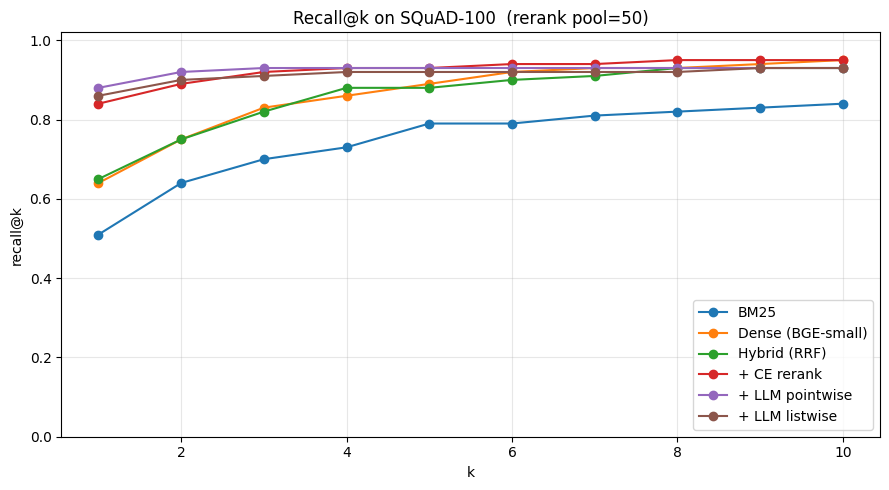

In [45]:
RANK_COLS = [
    ("BM25",              "bm25_ranks"),
    ("Dense (BGE-small)", "dense_ranks"),
    ("Hybrid (RRF)",      "hybrid_ranks"),
    ("+ CE rerank",       "ce_ranks"),
    ("+ LLM pointwise",   "pw_ranks"),
    ("+ LLM listwise",    "lw_ranks"),
]
curves = {}
for label, col in RANK_COLS:
    if col not in df.columns: continue
    if df[col].isna().any():  continue   # LLM stage skipped (no API key)
    curves[label] = recall_curve(df[col], gold)

plot_curves(curves, title=f"Recall@k on SQuAD-{N_DOCS}  (rerank pool={RERANK_N})")


## 10. Honest caveats

- **SQuAD is lexically easy.** Questions are written from the paragraph, so BM25 is an
  unusually strong baseline and hybrid's gain is dampened. Real-world corpora (legal,
  medical, multilingual) skew the comparison toward dense and rerankers. Same disclaimer
  applies as in the M10 deck.
- **N = 100 is tiny.** Differences smaller than ~3 percentage points are not reliable.
  Treat this notebook as a working **shape** of the leaderboard, not the final word —
  M10's larger sweep is more trustworthy.
- **Reranking can't recover what its candidate pool dropped.** CE and listwise both
  rerank hybrid's top-`RERANK_N=50`; pointwise reranks only hybrid's top-
  `POINTWISE_TOPK=10` (the realistic production setup, because pointwise LLM scoring
  doesn't scale to large pools — see "API rate limit" note in Section 7). So
  pointwise's recall@k for k > `POINTWISE_TOPK` matches hybrid by construction.
- **Listwise usually beats pointwise** at ~1/N the calls — this is the headline
  result of the RankGPT paper, and we expect to see it here on a small scale.
- **Cost numbers** use Claude haiku 4.5 list price; tune `PRICE_IN_PER_M` /
  `PRICE_OUT_PER_M` if you switch model.


## 11. What we did **not** cover (M15 part 2 & M16)

- **Query rewriting / decomposition** — HyDE, multi-query, step-back. (M15 part 2.)
- **Multi-hop / agentic retrieval** — ReAct-RAG, self-RAG, FLARE, IRCoT. (M15 part 2.)
- **End-to-end RAG evaluation** — RAGAS-style faithfulness, answer relevance, context
  precision/recall. (M16.)
- **Reliability layer** — LLM relevance filter, hallucination check, citation
  extraction (the `reliable_rag.ipynb` techniques). (M16.)
- **Safety & production** — indirect prompt injection from retrieved docs, observability,
  caching, long-context vs RAG. (M16.)
